# 01. K-ETS VWAP

K-ETS 가격 예측에서 사용할 날짜별 대표 가격 계열과 30일/60일 forward return 타겟을 정의한다.

같은 날짜에 실제 거래된 KAU 빈티지가 여러 개 있으면 해당 날짜의 거래대금과 거래량을 합쳐 **전체 거래 VWAP**를 다시 계산한다. 이렇게 만든 날짜별 단일 가격 계열을 `market_vwap`이라고 부른다.

`market_vwap` 계열 안에서 기준일 이후 30일 또는 60일이 지난 뒤 처음 관측되는 거래일을 미래 시점으로 잡고, 로그수익률을 타겟으로 계산한다.

## 1. 용어 정의

| 용어 | 정의 |
|---|---|
| `vintage` | KRX ETS 데이터의 `KAU15`, `KAU16` 같은 배출권 종목 구분이다. 데이터에서는 `isu_code`로 표현된다. |
| `vwap` | 원천 테이블의 `가중평균` 컬럼이다. 개별 vintage 단위의 거래량 가중 평균 가격이다. |
| `market_vwap` | 같은 날짜에 실제 거래된 모든 KAU vintage의 거래대금 합계를 거래량 합계로 나누어 다시 계산한 날짜별 대표 VWAP이다. |
| `is_blended` | 한 날짜의 `market_vwap`가 2개 이상의 vintage 거래를 합쳐 계산되었는지 표시하는 컬럼이다. |
| `same_panel_30d`, `same_panel_60d` | 동일한 `market_vwap` 단일 패널 안에서 기준일 + 30일 또는 + 60일 이후 첫 관측치를 미래 가격으로 찾았는지 표시하는 컬럼이다. |
| `target_logret_30d`, `target_logret_60d` | 기준일 `market_vwap` 대비 미래 `market_vwap`의 로그수익률이다. |

In [1]:
# C01. 환경 설정
from pathlib import Path
import json
import os
import warnings
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from IPython.display import display

try:
    import koreanize_matplotlib
except ImportError:
    pass

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / '.env').exists() and (PROJECT_ROOT.parent / '.env').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_DIR = PROJECT_ROOT / 'data' / 'processed' / 'targets'
SAVE_OUTPUTS = True

## 2. 원천 데이터 로드 기준

타겟은 `raw.krx_ets_daily`에서 만든다. 필요한 컬럼은 거래일, vintage 코드, 가격, 거래량, 거래대금, 원천 VWAP이다.

실제 거래가 없는 행은 타겟 가격 계산에서 제외한다. `acc_trdvol > 0`이고 `vwap > 0`인 행을 실제 거래 관측치로 본다. \
`market_vwap`는 가능한 경우 `sum(acc_trdval) / sum(acc_trdvol)`로 계산하고, 거래대금이 비어 있는 경우에는 `sum(vwap * acc_trdvol) / sum(acc_trdvol)`을 계산값으로 사용한다.

In [2]:
# C02. DB 연결 및 데이터 로드
load_dotenv(PROJECT_ROOT / '.env')

required_keys = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [key for key in required_keys if not os.getenv(key)]
if missing:
    raise RuntimeError(f'필수 DB 환경변수가 없습니다: {missing}')

user = os.getenv('DB_USER')
password = quote_plus(os.getenv('DB_PASSWORD'))
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

try:
    import psycopg
    db_driver = 'psycopg'
except ImportError:
    import psycopg2
    db_driver = 'psycopg2'

engine = create_engine(f'postgresql+{db_driver}://{user}:{password}@{host}:{port}/{db_name}')

query = """
select
    period,
    trd_dd,
    isu_code,
    clsprc,
    chgh,
    chgh_rt,
    opr,
    hpr,
    lpr,
    acc_trdvol,
    acc_trdval,
    vwap
from raw.krx_ets_daily
order by trd_dd, isu_code
"""

with engine.connect() as conn:
    ets = pd.read_sql(query, conn)

ets['trd_dd'] = pd.to_datetime(ets['trd_dd'])
for col in ['clsprc', 'chgh', 'chgh_rt', 'opr', 'hpr', 'lpr', 'acc_trdvol', 'acc_trdval', 'vwap']:
    ets[col] = pd.to_numeric(ets[col], errors='coerce')

ets['isu_year'] = ets['isu_code'].astype(str).str.extract(r'(\d{2})$')[0].astype(float) + 2000
ets['is_trade_day'] = ets['acc_trdvol'].gt(0) & ets['vwap'].gt(0)
ets_trade = ets.loc[ets['is_trade_day']].copy()

print(f'전체 관측치: {len(ets):,}')
print(f'실제 거래 관측치: {len(ets_trade):,}')
print(f'거래일 범위: {ets["trd_dd"].min().date()} ~ {ets["trd_dd"].max().date()}')
print(f'빈티지 수: {ets["isu_code"].nunique():,}')

전체 관측치: 8,213
실제 거래 관측치: 2,385
거래일 범위: 2015-01-12 ~ 2026-04-23
빈티지 수: 16


In [3]:
# C03. 기본 구조 및 0/결측 확인
basic_summary = pd.DataFrame({
    'item': ['전체 행 수', '실제 거래 행 수', '거래일 수', 'vintage 수', '중복 키(trd_dd, isu_code)'],
    'value': [
        len(ets),
        len(ets_trade),
        ets['trd_dd'].nunique(),
        ets['isu_code'].nunique(),
        ets.duplicated(['trd_dd', 'isu_code']).sum(),
    ],
})

check_cols = ['clsprc', 'opr', 'hpr', 'lpr', 'acc_trdvol', 'acc_trdval', 'vwap']
quality_summary = pd.DataFrame({
    'column': check_cols,
    'missing_count': [ets[col].isna().sum() for col in check_cols],
    'zero_count': [ets[col].eq(0).sum() for col in check_cols],
    'zero_rate': [ets[col].eq(0).mean() for col in check_cols],
})

basic_summary_display = basic_summary.rename(columns={'item': '항목', 'value': '값'})
quality_summary_display = quality_summary.rename(columns={
    'column': '컬럼',
    'missing_count': '결측 수',
    'zero_count': '0 값 수',
    'zero_rate': '0 값 비율',
})

display(basic_summary_display)
display(quality_summary_display)

,항목,값
0,전체 행 수,8213
1,실제 거래 행 수,2385
2,거래일 수,2770
3,vintage 수,16
4,"중복 키(trd_dd, isu_code)",0


,컬럼,결측 수,0 값 수,0 값 비율
0,clsprc,0,0,0.000000
1,opr,0,5913,0.719956
2,hpr,0,5913,0.719956
3,lpr,0,5913,0.719956
4,acc_trdvol,0,5828,0.709607
5,acc_trdval,0,5828,0.709607
6,vwap,0,5828,0.709607


## 3. 빈티지 중복 확인

`market_vwap`는 날짜별 단일 가격 계열이다. 따라서 먼저 같은 날짜에 실제 거래된 vintage가 몇 개인지 확인한다. \
하나의 vintage만 거래된 날짜에는 `market_vwap`가 해당 vintage의 VWAP와 거의 같다. 2개 이상의 vintage가 거래된 날짜에는 여러 vintage의 거래를 합쳐 대표 가격을 계산한다.

In [4]:
# C04. 날짜별 실제 거래 vintage 수 확인
daily_overlap = (
    ets.groupby('trd_dd')
    .agg(
        listed_vintage_count=('isu_code', 'nunique'),
        traded_vintage_count=('is_trade_day', 'sum'),
    )
    .reset_index()
)

overlap_distribution = (
    daily_overlap['traded_vintage_count']
    .value_counts()
    .sort_index()
    .rename_axis('traded_vintage_count')
    .reset_index(name='trading_days')
)
overlap_distribution['share'] = overlap_distribution['trading_days'] / overlap_distribution['trading_days'].sum()

overlap_distribution_display = overlap_distribution.rename(columns={
    'traded_vintage_count': '하루 실제 거래 vintage 수',
    'trading_days': '거래일 수',
    'share': '비율',
})

display(overlap_distribution_display)

,하루 실제 거래 vintage 수,거래일 수,비율
0,0,638,0.230325
1,1,1880,0.678700
2,2,251,0.090614
3,3,1,0.000361


In [5]:
# C05. 빈티지별 거래 기간과 거래일 수
vintage_summary = (
    ets_trade.groupby('isu_code')
    .agg(
        trade_start=('trd_dd', 'min'),
        trade_end=('trd_dd', 'max'),
        trade_obs=('trd_dd', 'size'),
        total_volume=('acc_trdvol', 'sum'),
        total_value=('acc_trdval', 'sum'),
        median_vwap=('vwap', 'median'),
    )
    .reset_index()
    .sort_values('isu_code')
)

vintage_summary_display = vintage_summary.rename(columns={
    'isu_code': 'vintage',
    'trade_start': '거래 시작일',
    'trade_end': '거래 종료일',
    'trade_obs': '실제 거래 관측치',
    'total_volume': '총 거래량',
    'total_value': '총 거래대금',
    'median_vwap': 'VWAP 중앙값',
})

display(vintage_summary_display)

,vintage,거래 시작일,거래 종료일,실제 거래 관측치,총 거래량,총 거래대금,VWAP 중앙값
0,KAU15,2015-01-12,2016-06-23,33,1620224,26424828100,17000.0
1,KAU16,2016-07-04,2017-06-30,134,8993600,183951421250,20535.5
2,KAU17,2017-02-06,2018-08-09,250,21754596,478747725450,21902.5
3,KAU18,2018-01-17,2019-09-27,154,7520475,200420296900,27994.0
4,KAU19,2019-01-22,2020-09-11,291,10511590,331357246200,31892.0
5,KAU20,2019-09-24,2021-08-09,285,13974616,258670218550,21000.0
6,KAU21,2021-01-14,2022-08-08,266,10402374,248690664600,26616.5
7,KAU22,2022-06-14,2023-08-31,284,48141257,558876079360,13572.5
8,KAU23,2023-06-20,2024-08-30,267,67971324,590020373000,8988.0
9,KAU24,2024-06-27,2025-08-29,248,72101808,674615936100,9147.5


## 4. 날짜별 전체 거래 VWAP 계산

`market_vwap`는 다음 식으로 계산한다.

$$
\mathrm{market\_vwap}_t = \frac{\sum_i \mathrm{acc\_trdval}_{t,i}}{\sum_i \mathrm{acc\_trdvol}_{t,i}}
$$

여기서 \(i\)는 같은 날짜에 실제 거래된 KAU vintage를 뜻한다. 이 계산은 모든 거래일에 동일하게 적용된다. \
다만 `n_vintages = 1`인 날짜에는 결과적으로 단일 vintage의 VWAP와 같고, `n_vintages >= 2`인 날짜에는 여러 vintage를 가중평균한 값이 된다.

In [6]:
# C06. market_vwap 생성

def join_codes(codes):
    return ','.join(sorted(pd.Series(codes).astype(str).unique()))

market_base = ets_trade.copy()
market_base['weighted_vwap_value'] = market_base['vwap'] * market_base['acc_trdvol']

market_daily = (
    market_base.groupby('trd_dd')
    .agg(
        total_trdvol=('acc_trdvol', 'sum'),
        total_trdval=('acc_trdval', 'sum'),
        weighted_vwap_value=('weighted_vwap_value', 'sum'),
        n_vintages=('isu_code', 'nunique'),
        vintages=('isu_code', join_codes),
        min_vwap=('vwap', 'min'),
        max_vwap=('vwap', 'max'),
    )
    .reset_index()
    .sort_values('trd_dd')
)

market_daily['market_vwap_from_value'] = market_daily['total_trdval'] / market_daily['total_trdvol']
market_daily['market_vwap_from_rows'] = market_daily['weighted_vwap_value'] / market_daily['total_trdvol']
market_daily['market_vwap'] = np.where(
    market_daily['total_trdval'].gt(0),
    market_daily['market_vwap_from_value'],
    market_daily['market_vwap_from_rows'],
)
market_daily['is_blended'] = market_daily['n_vintages'].gt(1)
market_daily['vwap_range'] = market_daily['max_vwap'] - market_daily['min_vwap']

market_daily = market_daily[[
    'trd_dd', 'market_vwap', 'total_trdvol', 'total_trdval', 'n_vintages', 'vintages',
    'is_blended', 'min_vwap', 'max_vwap', 'vwap_range', 'market_vwap_from_value', 'market_vwap_from_rows'
]].copy()

market_summary = pd.DataFrame([
    {'item': 'market_vwap 관측일 수', 'value': len(market_daily)},
    {'item': '2개 이상 vintage 거래일 수', 'value': int(market_daily['is_blended'].sum())},
    {'item': '2개 이상 vintage 거래일 비율', 'value': market_daily['is_blended'].mean()},
    {'item': 'market_vwap 시작일', 'value': market_daily['trd_dd'].min().date()},
    {'item': 'market_vwap 종료일', 'value': market_daily['trd_dd'].max().date()},
])

market_summary_display = market_summary.rename(columns={'item': '항목', 'value': '값'})
display(market_summary_display)

,항목,값
0,market_vwap 관측일 수,2132
1,2개 이상 vintage 거래일 수,252
2,2개 이상 vintage 거래일 비율,0.118199
3,market_vwap 시작일,2015-01-12
4,market_vwap 종료일,2026-04-23


In [7]:
# C07. 중복되는 vintage 구간의 market_vwap
blended_days = market_daily.loc[market_daily['is_blended']].copy()
blended_days_display = blended_days[[
    'trd_dd', 'vintages', 'n_vintages', 'market_vwap', 'total_trdvol',
    'total_trdval', 'min_vwap', 'max_vwap', 'vwap_range'
]].head(20)

blended_days_display = blended_days_display.rename(columns={
    'trd_dd': '거래일',
    'vintages': '거래 vintage',
    'n_vintages': 'vintage 수',
    'total_trdvol': '총 거래량',
    'total_trdval': '총 거래대금',
    'min_vwap': '최저 vintage VWAP',
    'max_vwap': '최고 vintage VWAP',
    'vwap_range': 'vintage 간 VWAP 차이',
})

blended_days_display

,거래일,거래 vintage,vintage 수,market_vwap,총 거래량,총 거래대금,최저 vintage VWAP,최고 vintage VWAP,vintage 간 VWAP 차이
79,2017-02-06,"KAU16,KAU17",2,25964.549445,7746,201121400,25900,26000,100
95,2017-03-06,"KAU16,KAU17",2,23210.447591,35032,813108400,23000,23700,700
97,2017-03-09,"KAU16,KAU17",2,22628.571429,35000,792000000,22500,22950,450
102,2017-03-16,"KAU16,KAU17",2,21400.000000,125000,2675000000,21400,21400,0
104,2017-03-20,"KAU16,KAU17",2,20784.615385,13000,270200000,20200,21720,1520
115,2017-04-04,"KAU16,KAU17",2,20603.448276,290000,5975000000,20500,20611,111
117,2017-04-06,"KAU16,KAU17",2,20588.888889,45000,926500000,20500,20767,267
120,2017-04-11,"KAU16,KAU17",2,20473.732719,217000,4442800000,20450,20488,38
121,2017-04-12,"KAU16,KAU17",2,20447.017675,241590,4939795000,20400,20452,52
122,2017-04-13,"KAU16,KAU17",2,20440.291262,103000,2105350000,20400,20450,50


## 5. 동일한 패널 내에서 30일/60일 미래 가격 찾기

타겟은 `market_vwap` 단일 패널 안에서 만든다. 기준일에서 30일 또는 60일이 지난 뒤, 그 날짜 이상에서 처음 관측되는 `market_vwap`를 미래 가격으로 사용한다.

| 컬럼 | 의미 |
|---|---|
| `future_date_30d`, `future_date_60d` | 기준일 + 30일 또는 + 60일 이후 처음 관측된 미래 거래일 |
| `future_vwap_30d`, `future_vwap_60d` | 미래 거래일의 `market_vwap` |
| `actual_elapsed_days_30d`, `actual_elapsed_days_60d` | 기준일과 미래 거래일 사이의 실제 경과일 |
| `target_logret_30d`, `target_logret_60d` | 기준일 대비 미래 `market_vwap` 로그수익률 |
| `same_panel_30d`, `same_panel_60d` | 동일한 `market_vwap` 패널에서 미래 가격을 찾을 수 있었는지 여부 |

거래 공백이나 마지막 구간 때문에 미래 가격이 없는 행은 타겟이 결측으로 남는다.

In [8]:
# C08. same-panel forward return 생성 함수

def add_same_panel_targets(price_df, horizons=(30, 60)):
    result = price_df.copy().sort_values('trd_dd').reset_index(drop=True)
    result['trd_dd'] = pd.to_datetime(result['trd_dd']).astype('datetime64[ns]')

    future_base = result[[
        'trd_dd', 'market_vwap', 'total_trdvol', 'total_trdval',
        'n_vintages', 'vintages', 'is_blended'
    ]].copy()
    date_values = future_base['trd_dd'].to_numpy(dtype='datetime64[ns]')

    for horizon in horizons:
        future_date_col = f'future_date_{horizon}d'
        future_vwap_col = f'future_vwap_{horizon}d'
        future_volume_col = f'future_total_trdvol_{horizon}d'
        future_value_col = f'future_total_trdval_{horizon}d'
        future_n_vintages_col = f'future_n_vintages_{horizon}d'
        future_vintages_col = f'future_vintages_{horizon}d'
        future_blended_col = f'future_is_blended_{horizon}d'
        elapsed_col = f'actual_elapsed_days_{horizon}d'
        target_col = f'target_logret_{horizon}d'
        same_panel_col = f'same_panel_{horizon}d'

        target_dates = result['trd_dd'] + pd.to_timedelta(horizon, unit='D')
        matched_pos = np.searchsorted(date_values, target_dates.to_numpy(dtype='datetime64[ns]'), side='left')
        valid = matched_pos < len(future_base)
        valid_idx = np.flatnonzero(valid)

        result[future_date_col] = pd.NaT
        result[future_vwap_col] = np.nan
        result[future_volume_col] = np.nan
        result[future_value_col] = np.nan
        result[future_n_vintages_col] = np.nan
        result[future_vintages_col] = pd.NA
        result[future_blended_col] = pd.NA
        result[elapsed_col] = np.nan
        result[target_col] = np.nan
        result[same_panel_col] = False

        if len(valid_idx) == 0:
            continue

        matched = future_base.iloc[matched_pos[valid]].reset_index(drop=True)
        result.loc[valid_idx, future_date_col] = matched['trd_dd'].to_numpy()
        result.loc[valid_idx, future_vwap_col] = matched['market_vwap'].to_numpy()
        result.loc[valid_idx, future_volume_col] = matched['total_trdvol'].to_numpy()
        result.loc[valid_idx, future_value_col] = matched['total_trdval'].to_numpy()
        result.loc[valid_idx, future_n_vintages_col] = matched['n_vintages'].to_numpy()
        result.loc[valid_idx, future_vintages_col] = matched['vintages'].to_numpy()
        result.loc[valid_idx, future_blended_col] = matched['is_blended'].to_numpy()

        result[elapsed_col] = (pd.to_datetime(result[future_date_col]) - result['trd_dd']).dt.days
        result[target_col] = np.log(result[future_vwap_col] / result['market_vwap'])
        result[same_panel_col] = result[target_col].notna()

    return result


target_df = add_same_panel_targets(market_daily, horizons=(30, 60))
target_df.head()

,trd_dd,market_vwap,total_trdvol,total_trdval,n_vintages,vintages,is_blended,min_vwap,max_vwap,vwap_range,market_vwap_from_value,market_vwap_from_rows,future_date_30d,future_vwap_30d,future_total_trdvol_30d,future_total_trdval_30d,future_n_vintages_30d,future_vintages_30d,future_is_blended_30d,actual_elapsed_days_30d,target_logret_30d,same_panel_30d,future_date_60d,future_vwap_60d,future_total_trdvol_60d,future_total_trdval_60d,future_n_vintages_60d,future_vintages_60d,future_is_blended_60d,actual_elapsed_days_60d,target_logret_60d,same_panel_60d
0,2015-01-12,8185.210084,1190,9740400,1,KAU15,False,8185,8185,0,8185.210084,8185.0,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,268.0,0.322474,True,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,268.0,0.322474,True
1,2015-01-13,9500.000000,50,475000,1,KAU15,False,9500,9500,0,9500.000000,9500.0,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,267.0,0.173511,True,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,267.0,0.173511,True
2,2015-01-14,9510.000000,100,951000,1,KAU15,False,9510,9510,0,9510.000000,9510.0,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,266.0,0.172459,True,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,266.0,0.172459,True
3,2015-01-16,9610.000000,40,384400,1,KAU15,False,9610,9610,0,9610.000000,9610.0,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,264.0,0.161999,True,2015-10-07,11300.0,12000.0,1.356000e+08,1.0,KAU15,False,264.0,0.161999,True
4,2015-10-07,11300.000000,12000,135600000,1,KAU15,False,11300,11300,0,11300.000000,11300.0,2015-12-09,12100.0,100000.0,1.210000e+09,1.0,KAU15,False,63.0,0.068403,True,2015-12-09,12100.0,100000.0,1.210000e+09,1.0,KAU15,False,63.0,0.068403,True


In [9]:
# C09. 타겟 생성률과 실제 경과일 요약
target_summary_rows = []
for horizon in [30, 60]:
    target_col = f'target_logret_{horizon}d'
    elapsed_col = f'actual_elapsed_days_{horizon}d'
    same_panel_col = f'same_panel_{horizon}d'
    valid = target_df[target_col].notna()
    elapsed = target_df.loc[valid, elapsed_col]

    target_summary_rows.append({
        'target': target_col,
        'same_panel_column': same_panel_col,
        'valid_rows': int(valid.sum()),
        'coverage': valid.mean(),
        'elapsed_min': elapsed.min(),
        'elapsed_median': elapsed.median(),
        'elapsed_max': elapsed.max(),
        'return_mean': target_df.loc[valid, target_col].mean(),
        'return_std': target_df.loc[valid, target_col].std(),
        'return_p05': target_df.loc[valid, target_col].quantile(0.05),
        'return_p50': target_df.loc[valid, target_col].quantile(0.50),
        'return_p95': target_df.loc[valid, target_col].quantile(0.95),
    })

target_summary = pd.DataFrame(target_summary_rows)
target_summary_display = target_summary.rename(columns={
    'target': '타겟',
    'same_panel_column': 'same_panel 컬럼',
    'valid_rows': '생성 행 수',
    'coverage': '생성률',
    'elapsed_min': '실제 경과일 최소',
    'elapsed_median': '실제 경과일 중앙값',
    'elapsed_max': '실제 경과일 최대',
    'return_mean': '수익률 평균',
    'return_std': '수익률 표준편차',
    'return_p05': '수익률 5%',
    'return_p50': '수익률 중앙값',
    'return_p95': '수익률 95%',
})

target_summary_display

,타겟,same_panel 컬럼,생성 행 수,생성률,실제 경과일 최소,실제 경과일 중앙값,실제 경과일 최대,수익률 평균,수익률 표준편차,수익률 5%,수익률 중앙값,수익률 95%
0,target_logret_30d,same_panel_30d,2110,0.989681,30.0,30.0,268.0,-0.002970,0.144673,-0.252166,0.004809,0.220271
1,target_logret_60d,same_panel_60d,2089,0.979831,60.0,60.0,268.0,-0.006521,0.203392,-0.389384,0.001317,0.320454


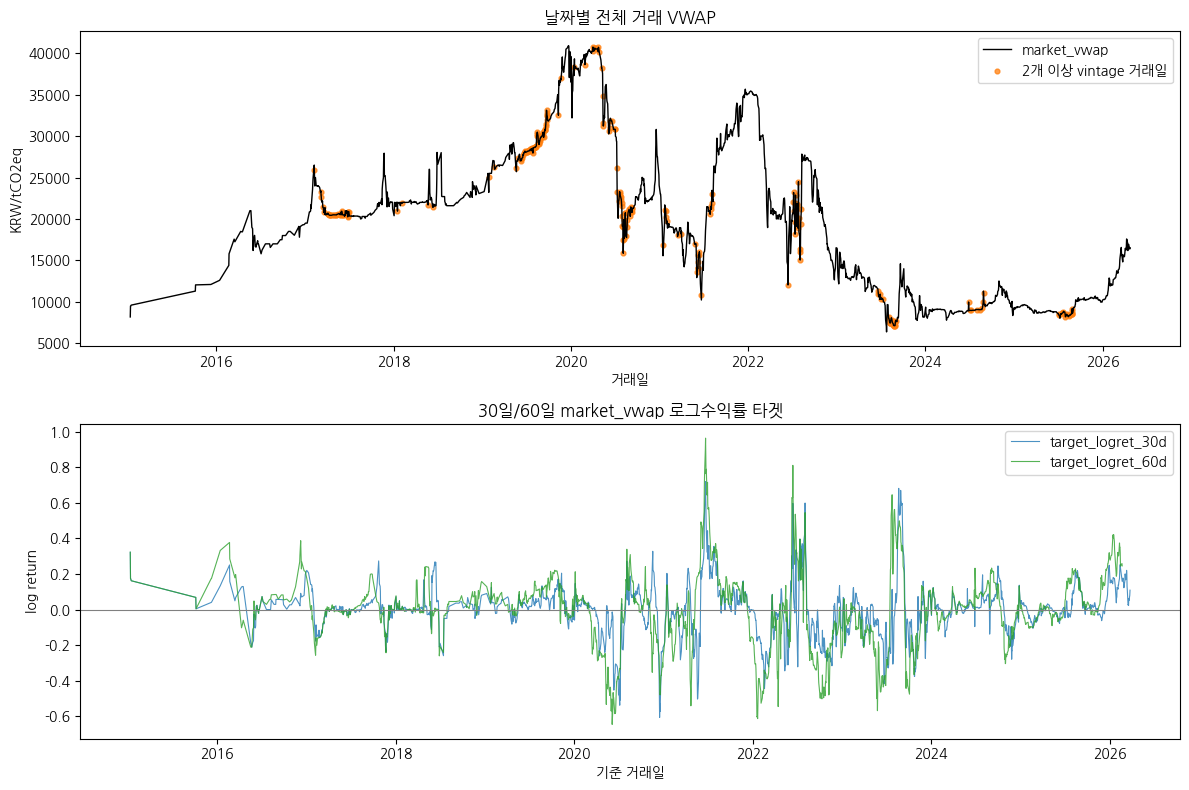

In [10]:
# C10. target_logret 분포와 market_vwap 흐름
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(target_df['trd_dd'], target_df['market_vwap'], color='black', linewidth=1.0, label='market_vwap')
blended_points = target_df.loc[target_df['is_blended']]
axes[0].scatter(
    blended_points['trd_dd'], blended_points['market_vwap'],
    s=12, color='tab:orange', alpha=0.75, label='2개 이상 vintage 거래일'
)
axes[0].set_title('날짜별 전체 거래 VWAP')
axes[0].set_xlabel('거래일')
axes[0].set_ylabel('KRW/tCO2eq')
axes[0].legend()

for horizon, color in [(30, 'tab:blue'), (60, 'tab:green')]:
    target_col = f'target_logret_{horizon}d'
    axes[1].plot(
        target_df['trd_dd'], target_df[target_col],
        linewidth=0.8, alpha=0.8, label=target_col, color=color,
    )
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('30일/60일 market_vwap 로그수익률 타겟')
axes[1].set_xlabel('기준 거래일')
axes[1].set_ylabel('log return')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 품질 정책 확인

미래 가격은 기준일 + 30일 또는 + 60일 이후 처음 관측되는 거래일에서 가져온다. 따라서 주말, 휴일, 거래 공백이 있으면 실제 경과일이 명목 기간보다 길어진다.

기본 정책 후보는 다음과 같이 둔다.

| 정책 | 의미 |
|---|---|
| `no_elapsed_filter` | 미래 가격이 있으면 모두 유지한다. |
| `nominal_plus_5` | 30일 타겟은 35일 이하, 60일 타겟은 65일 이하만 유지한다. |
| `nominal_plus_15` | 30일 타겟은 45일 이하, 60일 타겟은 75일 이하만 유지한다. |

`nominal_plus_15`는 거래 공백을 일정 부분 허용하면서도 지나치게 먼 미래값이 섞이는 것을 줄이는 후보 정책이다. 최종 모델링 파일을 저장하기 전에는 이 표에서 표본 수와 분포 변화를 확인한다.

In [11]:
# C11. elapsed cap 후보별 표본 수와 분포 비교
policy_specs = [
    {'policy': 'no_elapsed_filter', 'cap_30d': None, 'cap_60d': None},
    {'policy': 'nominal_plus_5', 'cap_30d': 35, 'cap_60d': 65},
    {'policy': 'nominal_plus_15', 'cap_30d': 45, 'cap_60d': 75},
]

policy_rows = []
for spec in policy_specs:
    for horizon in [30, 60]:
        target_col = f'target_logret_{horizon}d'
        elapsed_col = f'actual_elapsed_days_{horizon}d'
        cap = spec[f'cap_{horizon}d']

        valid = target_df[target_col].notna()
        if cap is not None:
            valid = valid & target_df[elapsed_col].le(cap)

        x = target_df.loc[valid, target_col]
        policy_rows.append({
            'policy': spec['policy'],
            'target': target_col,
            'elapsed_cap': cap,
            'rows': int(valid.sum()),
            'coverage': valid.mean(),
            'mean': x.mean(),
            'std': x.std(),
            'p01': x.quantile(0.01),
            'p05': x.quantile(0.05),
            'p50': x.quantile(0.50),
            'p95': x.quantile(0.95),
            'p99': x.quantile(0.99),
        })

policy_comparison = pd.DataFrame(policy_rows)
policy_comparison_display = policy_comparison.rename(columns={
    'policy': '정책',
    'target': '타겟',
    'elapsed_cap': '경과일 상한',
    'rows': '표본 수',
    'coverage': '생성률',
    'mean': '평균',
    'std': '표준편차',
})

policy_comparison_display

,정책,타겟,경과일 상한,표본 수,생성률,평균,표준편차,p01,p05,p50,p95,p99
0,no_elapsed_filter,target_logret_30d,NaN,2110,0.989681,-0.002970,0.144673,-0.388117,-0.252166,0.004809,0.220271,0.488707
1,no_elapsed_filter,target_logret_60d,NaN,2089,0.979831,-0.006521,0.203392,-0.504733,-0.389384,0.001317,0.320454,0.552527
2,nominal_plus_5,target_logret_30d,35.0,2046,0.959662,-0.004600,0.144874,-0.398552,-0.253568,0.003838,0.219277,0.484892
3,nominal_plus_5,target_logret_60d,65.0,2028,0.951220,-0.008746,0.205051,-0.507784,-0.390810,0.000000,0.320885,0.558746
4,nominal_plus_15,target_logret_30d,45.0,2094,0.982176,-0.003344,0.144583,-0.390453,-0.251766,0.004701,0.219679,0.491025
5,nominal_plus_15,target_logret_60d,75.0,2074,0.972795,-0.007296,0.203611,-0.505483,-0.389745,0.000361,0.320094,0.554056


In [12]:
# C12. nominal_plus_15 기준에서 제외되는 긴 경과일 행 확인
long_gap_rows = []
for horizon, cap in [(30, 45), (60, 75)]:
    target_col = f'target_logret_{horizon}d'
    elapsed_col = f'actual_elapsed_days_{horizon}d'
    future_date_col = f'future_date_{horizon}d'
    future_vwap_col = f'future_vwap_{horizon}d'

    mask = target_df[target_col].notna() & target_df[elapsed_col].gt(cap)
    cols = [
        'trd_dd', 'market_vwap', 'n_vintages', 'vintages',
        future_date_col, future_vwap_col, elapsed_col, target_col,
    ]
    tmp = target_df.loc[mask, cols].copy()
    tmp.insert(0, 'target_horizon', horizon)
    long_gap_rows.append(tmp)

long_gap_examples = pd.concat(long_gap_rows, ignore_index=True) if long_gap_rows else pd.DataFrame()
long_gap_examples.head(20)

,target_horizon,trd_dd,market_vwap,n_vintages,vintages,future_date_30d,future_vwap_30d,actual_elapsed_days_30d,target_logret_30d,future_date_60d,future_vwap_60d,actual_elapsed_days_60d,target_logret_60d
0,30,2015-01-12,8185.210084,1,KAU15,2015-10-07,11300.0,268.0,0.322474,NaT,NaN,NaN,NaN
1,30,2015-01-13,9500.000000,1,KAU15,2015-10-07,11300.0,267.0,0.173511,NaT,NaN,NaN,NaN
2,30,2015-01-14,9510.000000,1,KAU15,2015-10-07,11300.0,266.0,0.172459,NaT,NaN,NaN,NaN
3,30,2015-01-16,9610.000000,1,KAU15,2015-10-07,11300.0,264.0,0.161999,NaT,NaN,NaN,NaN
4,30,2015-10-07,11300.000000,1,KAU15,2015-12-09,12100.0,63.0,0.068403,NaT,NaN,NaN,NaN
5,30,2015-10-08,12050.000000,1,KAU15,2015-12-09,12100.0,62.0,0.004141,NaT,NaN,NaN,NaN
6,30,2016-02-22,14400.000000,1,KAU15,2016-04-11,18500.0,49.0,0.250543,NaT,NaN,NaN,NaN
7,30,2016-02-23,15800.000000,1,KAU15,2016-04-11,18500.0,48.0,0.157761,NaT,NaN,NaN,NaN
8,30,2018-07-16,28000.000000,1,KAU17,2018-09-05,21600.0,51.0,-0.259511,NaT,NaN,NaN,NaN
9,30,2018-07-17,25200.000000,1,KAU17,2018-09-05,21600.0,50.0,-0.154151,NaT,NaN,NaN,NaN


## 7. 스키마 저장

`SAVE_OUTPUTS = True`로 바꾸면 모델링용 타겟 파일과 schema 초안을 저장한다.

In [13]:
# C13. schema 확인 및 저장
column_descriptions = {
    'trd_dd': '기준 거래일',
    'market_vwap': '기준일 전체 거래 VWAP',
    'total_trdvol': '기준일 전체 거래량',
    'total_trdval': '기준일 전체 거래대금',
    'n_vintages': '기준일 실제 거래 vintage 수',
    'vintages': '기준일 실제 거래 vintage 목록',
    'is_blended': '2개 이상 vintage 거래를 합산했는지 여부',
    'min_vwap': '기준일 vintage별 VWAP 최솟값',
    'max_vwap': '기준일 vintage별 VWAP 최댓값',
    'vwap_range': '기준일 vintage별 VWAP 범위',
    'future_date_30d': '30일 이후 처음 관측된 미래 거래일',
    'future_vwap_30d': '30일 미래 market_vwap',
    'actual_elapsed_days_30d': '30일 타겟의 실제 경과일',
    'target_logret_30d': '30일 market_vwap 로그수익률',
    'same_panel_30d': '동일 market_vwap 패널에서 30일 미래값을 찾았는지 여부',
    'future_date_60d': '60일 이후 처음 관측된 미래 거래일',
    'future_vwap_60d': '60일 미래 market_vwap',
    'actual_elapsed_days_60d': '60일 타겟의 실제 경과일',
    'target_logret_60d': '60일 market_vwap 로그수익률',
    'same_panel_60d': '동일 market_vwap 패널에서 60일 미래값을 찾았는지 여부',
}

schema_rows = [
    {'column': col, 'dtype': str(target_df[col].dtype), 'description': column_descriptions.get(col, '')}
    for col in target_df.columns
]
schema_df = pd.DataFrame(schema_rows)
display(schema_df)

if SAVE_OUTPUTS:
    TARGET_DIR.mkdir(parents=True, exist_ok=True)
    target_path = TARGET_DIR / 'market_vwap_targets.parquet'
    schema_path = TARGET_DIR / 'market_vwap_targets.schema.json'
    target_df.to_parquet(target_path, index=False)
    schema_path.write_text(json.dumps(schema_rows, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Saved target dataset: {target_path}')
    print(f'Saved schema: {schema_path}')
else:
    print('SAVE_OUTPUTS=False 이므로 파일을 저장하지 않았습니다.')

,column,dtype,description
0,trd_dd,datetime64[ns],기준 거래일
1,market_vwap,float64,기준일 전체 거래 VWAP
2,total_trdvol,int64,기준일 전체 거래량
3,total_trdval,int64,기준일 전체 거래대금
4,n_vintages,int64,기준일 실제 거래 vintage 수
5,vintages,str,기준일 실제 거래 vintage 목록
6,is_blended,bool,2개 이상 vintage 거래를 합산했는지 여부
7,min_vwap,int64,기준일 vintage별 VWAP 최솟값
8,max_vwap,int64,기준일 vintage별 VWAP 최댓값
9,vwap_range,int64,기준일 vintage별 VWAP 범위


Saved target dataset: /mnt/hgfs/Windows/Climate/data/processed/targets/market_vwap_targets.parquet
Saved schema: /mnt/hgfs/Windows/Climate/data/processed/targets/market_vwap_targets.schema.json
